# Animal Accidents and Decision Tree Classification

In [208]:
import pandas as pd
import matplotlib.pyplot as plt

In [209]:
riista_df = pd.read_csv("../data/riistaonnettomuudet_2017_2020.csv", sep=",", encoding="latin1")
maakunta_df = pd.read_csv("../data/maakunnat_pinta_alat.csv", sep=";", encoding="latin1")

In [210]:
riista_df.head()

,id,tapahtumaAika,vuosi,kuukausi,x,y,kunta,kuntaNimi,maakunta,maakuntaNimi,tielaji,tielajis,tieNumero,tieYllapito,tieYllapitoNimi,riistalaji,riistalajiNimi
0,1,2017-12-10T16:55:00.000+02:00,2017,12,278773.659,6980877.550,743,Seinäjoki,14,Etelä-Pohjanmaa,3,Valtatie,18.0,1.0,Valtio,47507,Metsäkauris
1,2,2017-09-03T13:00:00.000+03:00,2017,9,397501.008,7503083.730,261,Kittilä,19,Lappi,4,Kantatie,80.0,1.0,Valtio,47503,Hirvi
2,3,2017-09-18T07:00:00.000+03:00,2017,9,418353.841,7514104.657,261,Kittilä,19,Lappi,6,Muu maantie,9552.0,1.0,Valtio,47503,Hirvi
3,4,2017-12-01T17:00:00.000+02:00,2017,12,488970.827,6722504.397,285,Kotka,8,Kymenlaakso,5,Seututie,357.0,1.0,Valtio,47629,Valkohäntäpeura
4,5,2017-09-18T07:00:00.000+03:00,2017,9,418766.580,7506930.833,261,Kittilä,19,Lappi,6,Muu maantie,9552.0,1.0,Valtio,47503,Hirvi


In [211]:
maakunta_df.head()

,"id,gml_id,natcode,namefin,nameswe,area"
0,"1,1601110001,01,Uusimaa,Nyland,9109841425"
1,"2,1601110027,15,Pohjanmaa,Ãsterbotten,7380547465"
2,"3,1601110035,19,Lappi,Lappland,94206757384"
3,"4,1601110011,07,PÃ¤ijÃ¤t-HÃ¤me,PÃ¤ijÃ¤nne-Tava..."
4,"5,1601110037,21,Ahvenanmaan maakunta,Landskape..."


In [212]:
print(riista_df.columns.tolist())
print(maakunta_df.columns.tolist())

['id', 'tapahtumaAika', 'vuosi', 'kuukausi', 'x', 'y', 'kunta', 'kuntaNimi', 'maakunta', 'maakuntaNimi', 'tielaji', 'tielajis', 'tieNumero', 'tieYllapito', 'tieYllapitoNimi', 'riistalaji', 'riistalajiNimi']
['id,gml_id,natcode,namefin,nameswe,area']


In [213]:
riista_df["riistalajiNimi"].value_counts()

riistalajiNimi
Valkohäntäpeura    31703
Metsäkauris        22466
Hirvi               9193
Metsäpeura           325
Villisika            168
Kuusipeura            87
Name: count, dtype: int64

In [214]:
riista_df["riistalajiNimi"].value_counts()

riistalajiNimi
Valkohäntäpeura    31703
Metsäkauris        22466
Hirvi               9193
Metsäpeura           325
Villisika            168
Kuusipeura            87
Name: count, dtype: int64

In [215]:
top_animals = riista_df["riistalajiNimi"].value_counts().head(3).index

In [216]:
top_animals = riista_df["riistalajiNimi"].value_counts().head(3).index

In [217]:
riista_df = riista_df[riista_df["riistalajiNimi"].isin(top_animals)]

In [218]:
riista_df["riistalajiNimi"].value_counts()

riistalajiNimi
Valkohäntäpeura    31703
Metsäkauris        22466
Hirvi               9193
Name: count, dtype: int64

In [219]:
riista_df.columns
maakunta_df.columns

Index(['id,gml_id,natcode,namefin,nameswe,area'], dtype='str')

In [220]:
maakunta_df = pd.read_csv("../data/maakunnat_pinta_alat.csv", sep=",")

In [221]:
maakunta_df.columns

Index(['id', 'gml_id', 'natcode', 'namefin', 'nameswe', 'area'], dtype='str')

In [222]:
merged_df = riista_df.merge(
    maakunta_df,
    left_on="maakuntaNimi",
    right_on="namefin",
    how="left"
)

In [223]:
merged_df.head()

,id_x,tapahtumaAika,vuosi,kuukausi,x,y,kunta,kuntaNimi,maakunta,maakuntaNimi,...,tieYllapito,tieYllapitoNimi,riistalaji,riistalajiNimi,id_y,gml_id,natcode,namefin,nameswe,area
0,1,2017-12-10T16:55:00.000+02:00,2017,12,278773.659,6980877.550,743,Seinäjoki,14,Etelä-Pohjanmaa,...,1.0,Valtio,47507,Metsäkauris,6,1601110025,14,Etelä-Pohjanmaa,Södra Österbotten,13864807779
1,2,2017-09-03T13:00:00.000+03:00,2017,9,397501.008,7503083.730,261,Kittilä,19,Lappi,...,1.0,Valtio,47503,Hirvi,3,1601110035,19,Lappi,Lappland,94206757384
2,3,2017-09-18T07:00:00.000+03:00,2017,9,418353.841,7514104.657,261,Kittilä,19,Lappi,...,1.0,Valtio,47503,Hirvi,3,1601110035,19,Lappi,Lappland,94206757384
3,4,2017-12-01T17:00:00.000+02:00,2017,12,488970.827,6722504.397,285,Kotka,8,Kymenlaakso,...,1.0,Valtio,47629,Valkohäntäpeura,15,1601110013,8,Kymenlaakso,Kymmenedalen,4622479273
4,5,2017-09-18T07:00:00.000+03:00,2017,9,418766.580,7506930.833,261,Kittilä,19,Lappi,...,1.0,Valtio,47503,Hirvi,3,1601110035,19,Lappi,Lappland,94206757384


In [224]:
merged_df.columns

Index(['id_x', 'tapahtumaAika', 'vuosi', 'kuukausi', 'x', 'y', 'kunta',
       'kuntaNimi', 'maakunta', 'maakuntaNimi', 'tielaji', 'tielajis',
       'tieNumero', 'tieYllapito', 'tieYllapitoNimi', 'riistalaji',
       'riistalajiNimi', 'id_y', 'gml_id', 'natcode', 'namefin', 'nameswe',
       'area'],
      dtype='str')

In [225]:
merged_df["tapahtumaAika"] = pd.to_datetime(
    merged_df["tapahtumaAika"],
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

In [226]:
merged_df["hour"] = merged_df["tapahtumaAika"].dt.hour
merged_df["weekday"] = merged_df["tapahtumaAika"].dt.weekday

In [227]:
merged_df = merged_df.dropna(subset=["hour", "weekday"])

In [228]:
X = merged_df[["hour", "weekday", "area"]]
y = merged_df["riistalajiNimi"]

In [229]:
merged_df = riista_df.merge(
    maakunta_df,
    left_on="maakuntaNimi",
    right_on="namefin",
    how="left"
)

In [230]:
merged_df["tapahtumaAika"] = merged_df["tapahtumaAika"].astype(str)

merged_df["tapahtumaAika"] = pd.to_datetime(
    merged_df["tapahtumaAika"],
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

merged_df["hour"] = merged_df["tapahtumaAika"].dt.hour
merged_df["weekday"] = merged_df["tapahtumaAika"].dt.weekday
merged_df["month"] = merged_df["tapahtumaAika"].dt.month

merged_df = merged_df.dropna(subset=["hour", "weekday"])

In [231]:
X = merged_df[["hour", "weekday", "month", "area"]]
y = merged_df["riistalajiNimi"]

In [232]:
from sklearn.model_selection import train_test_split

In [233]:
X.head()
X.isnull().sum()

hour       0
weekday    0
month      0
area       0
dtype: int64

In [234]:
merged_df = merged_df.dropna(subset=["hour", "weekday", "month", "area"])

In [235]:
X = merged_df[["hour", "weekday", "month", "area"]]
y = merged_df["riistalajiNimi"]

In [236]:
print(X.shape)
print(y.shape)

(0, 4)
(0,)


In [237]:
print(X.isnull().sum())
print(y.isnull().sum())

hour       0
weekday    0
month      0
area       0
dtype: int64
0


In [238]:
print(X.dtypes)

hour       float64
weekday    float64
month      float64
area         int64
dtype: object


In [239]:
merged_df["area"] = pd.to_numeric(merged_df["area"], errors="coerce")

merged_df = merged_df.dropna(subset=["hour", "weekday", "month", "area", "riistalajiNimi"])

X = merged_df[["hour", "weekday", "month", "area"]]
y = merged_df["riistalajiNimi"]

In [240]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("X nulls:")
print(X.isnull().sum())
print()
print("y nulls:", y.isnull().sum())
print()
print("X dtypes:")
print(X.dtypes)
print()
print("y unique:")
print(y.value_counts())

X shape: (0, 4)
y shape: (0,)

X nulls:
hour       0
weekday    0
month      0
area       0
dtype: int64

y nulls: 0

X dtypes:
hour       float64
weekday    float64
month      float64
area         int64
dtype: object

y unique:
Series([], Name: count, dtype: int64)


In [241]:
merged_df = riista_df.merge(
    maakunta_df,
    left_on="maakuntaNimi",
    right_on="namefin",
    how="left"
)

In [242]:
merged_df["tapahtumaAika"].head(10)

0    2017-12-10T16:55:00.000+02:00
1    2017-09-03T13:00:00.000+03:00
2    2017-09-18T07:00:00.000+03:00
3    2017-12-01T17:00:00.000+02:00
4    2017-09-18T07:00:00.000+03:00
5    2017-12-10T22:30:00.000+02:00
6    2017-09-16T08:24:56.709+03:00
7    2017-09-09T08:30:00.000+03:00
8    2017-04-07T17:00:00.000+03:00
9    2017-12-29T00:24:42.249+02:00
Name: tapahtumaAika, dtype: str

In [243]:
merged_df["tapahtumaAika"] = merged_df["tapahtumaAika"].str.split("+").str[0]

In [244]:
merged_df["tapahtumaAika"] = pd.to_datetime(
    merged_df["tapahtumaAika"],
    errors="coerce"
)

In [245]:
merged_df["hour"] = merged_df["tapahtumaAika"].dt.hour
merged_df["weekday"] = merged_df["tapahtumaAika"].dt.weekday
merged_df["month"] = merged_df["tapahtumaAika"].dt.month

In [246]:
merged_df["area"] = pd.to_numeric(merged_df["area"], errors="coerce")

clean_df = merged_df.dropna(subset=["hour", "weekday", "month", "area", "riistalajiNimi"])

In [247]:
print(clean_df.shape)

(63362, 26)


In [248]:
X = clean_df[["hour", "weekday", "month", "area"]]
y = clean_df["riistalajiNimi"]

In [249]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [250]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [251]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

          Hirvi       0.43      0.43      0.43      1839
    Metsäkauris       0.44      0.39      0.42      4493
Valkohäntäpeura       0.63      0.68      0.65      6341

       accuracy                           0.54     12673
      macro avg       0.50      0.50      0.50     12673
   weighted avg       0.53      0.54      0.54     12673



In [252]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
3,area,0.331338
0,hour,0.294380
1,weekday,0.220920
2,month,0.153361


In [253]:
model2 = DecisionTreeClassifier(max_depth=5, random_state=42)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print(classification_report(y_test, y_pred2))

                 precision    recall  f1-score   support

          Hirvi       0.55      0.35      0.43      1839
    Metsäkauris       0.52      0.25      0.34      4493
Valkohäntäpeura       0.61      0.90      0.73      6341

       accuracy                           0.59     12673
      macro avg       0.56      0.50      0.50     12673
   weighted avg       0.57      0.59      0.55     12673



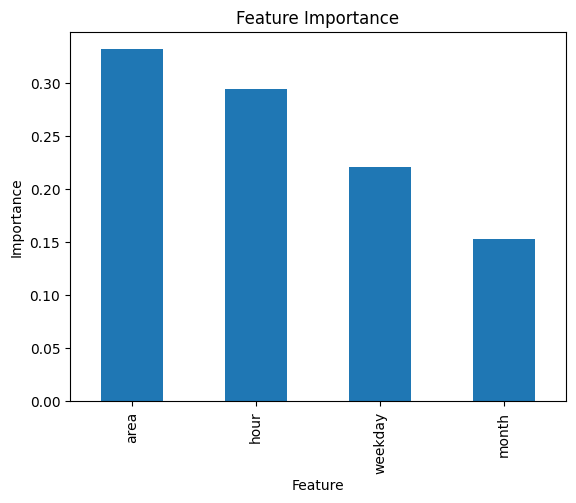

In [254]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

## What I am doing and why

In this notebook, I analyze wildlife accident data and build a Decision Tree classifier to predict which game animal was involved in an accident.

## What I plan to do next

I first clean the data, keep only the most common animal species, merge province area data, and create new features from time information. After that, I train and evaluate a Decision Tree model and test one improvement.

## Interpretation and critical reflection

The model can learn some patterns, but the prediction quality is limited because only a few simple features are used. A better model might be achieved by adding more geographical, seasonal, or road-related variables.